# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

# TODO: đặt BATCH_SIZE, EPOCHS, LEARNING_RATE, DATA_DIR
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3

# TODO: chọn DEVICE là 'cuda' nếu torch.cuda.is_available(), ngược lại 'cpu'
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
DATA_DIR = "./data"

torch.manual_seed(0)

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.13.0+cu130
Thiết bị: cpu


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [2]:
transform = transforms.Compose([
    transforms.Lambda(
        lambda image: transforms.functional.rotate(image, -90)
    ),
    transforms.Lambda(
        lambda image: transforms.functional.hflip(image)
    ),
    transforms.ToTensor()
])

full_train = datasets.EMNIST(
    DATA_DIR,
    split='letters',
    train=True,
    transform=transform,
    target_transform=lambda label: label - 1,
    download=True
)

test_set = datasets.EMNIST(
    DATA_DIR,
    split='letters',
    train=False,
    transform=transform,
    target_transform=lambda label: label - 1,
    download=True
)

# TODO: dùng random_split tách full_train thành train_set (100.000) và val_set (24.800)
train_set, val_set = random_split(
    full_train,
    [100_000, 24_800],
    generator=torch.Generator().manual_seed(42)
)
# TODO: tạo train_loader, val_loader, test_loader với batch_size=BATCH_SIZE
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


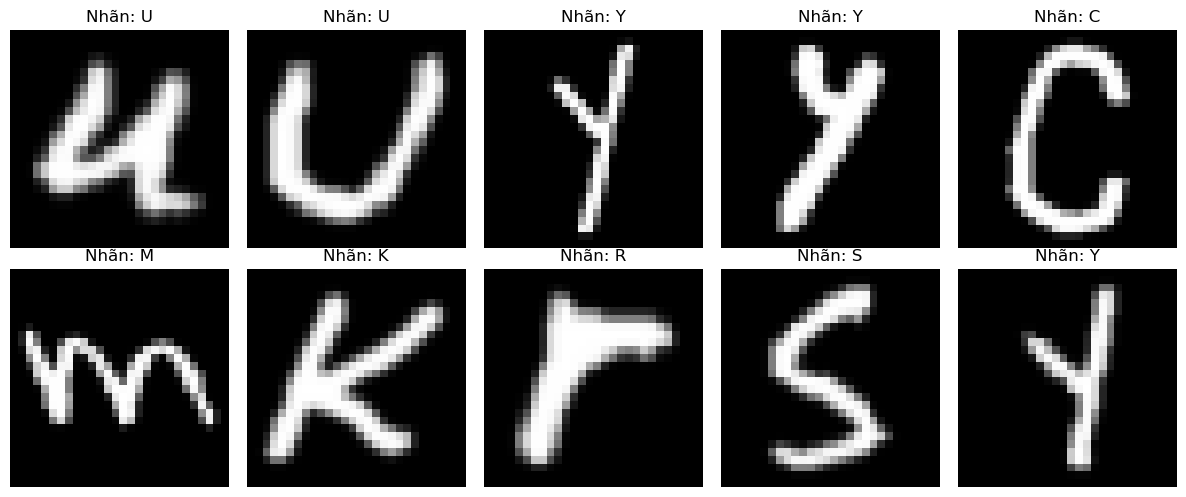

In [3]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# TODO: vẽ 10 ảnh đầu tiên của batch (cmap='gray'), tiêu đề mỗi ảnh là nhãn dạng chữ cái
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = batch_images[i].squeeze(0)
    label = batch_labels[i].item()
    letter = chr(label + ord('A'))

    ax.imshow(image, cmap='gray')
    ax.set_title(f'Nhãn: {letter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [4]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 26)

    def forward(self, images):
        images = self.flatten(images)
        images = self.fc1(images)
        images = self.relu(images)
        images = self.fc2(images)

        return images

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=26, bias=True)
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [6]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch}: "
        f"train loss={train_loss:.4f}, "
        f"val loss={val_loss:.4f}, "
        f"train acc={train_acc:.4f}, "
        f"val acc={val_acc:.4f}"
    )

Epoch 1: train loss=1.2484, val loss=0.8863, train acc=0.6575, val acc=0.7487
Epoch 2: train loss=0.7512, val loss=0.6613, train acc=0.7859, val acc=0.8102
Epoch 3: train loss=0.5895, val loss=0.5545, train acc=0.8286, val acc=0.8372
Epoch 4: train loss=0.5033, val loss=0.4993, train acc=0.8522, val acc=0.8520
Epoch 5: train loss=0.4510, val loss=0.4655, train acc=0.8661, val acc=0.8615


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

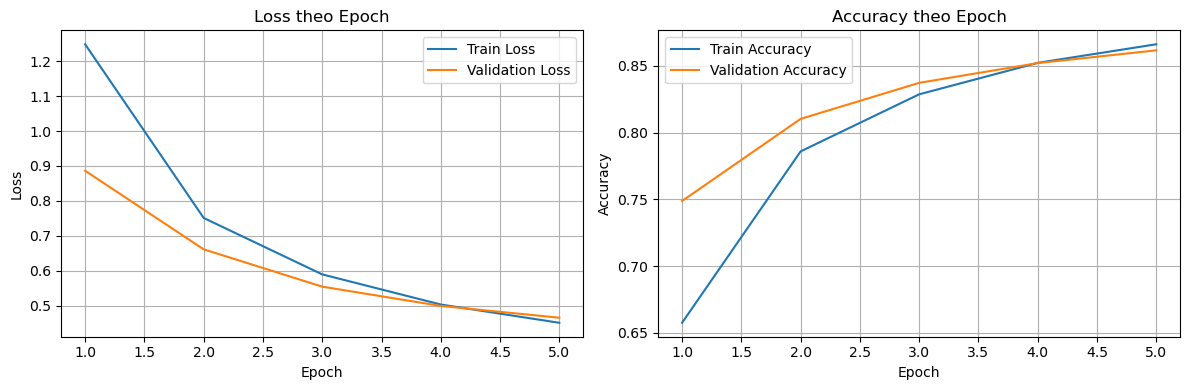

Test loss=0.4702, test accuracy=85.96%


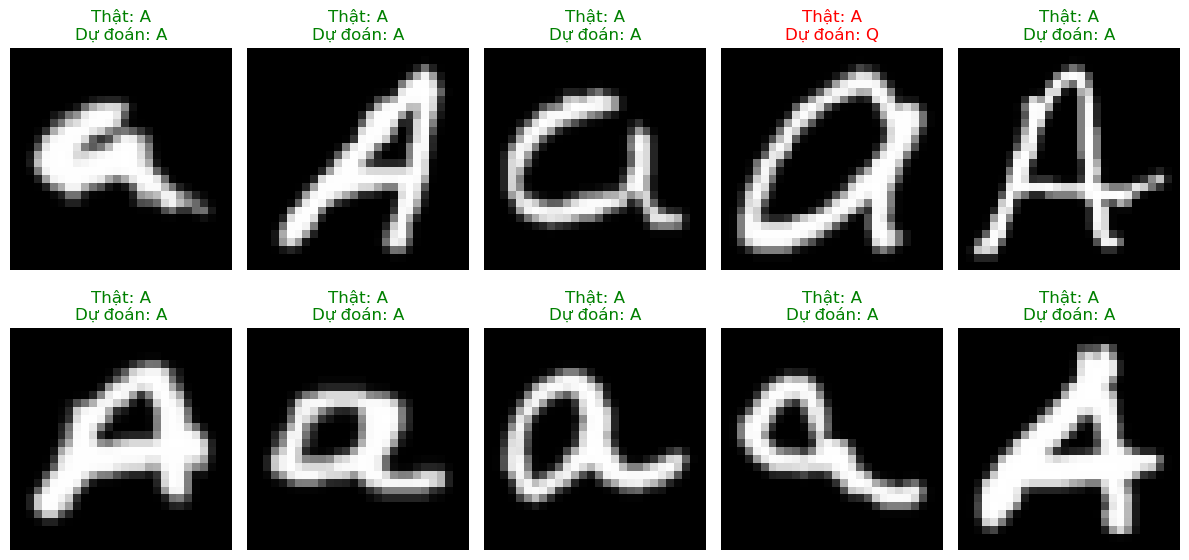

In [7]:
# TODO: vẽ đồ thị Loss và Accuracy theo epoch (train vs val)

epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ Loss
axes[0].plot(epochs, train_losses, label='Train Loss')
axes[0].plot(epochs, val_losses, label='Validation Loss')
axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Biểu đồ Accuracy
axes[1].plot(epochs, train_accuracies, label='Train Accuracy')
axes[1].plot(epochs, val_accuracies, label='Validation Accuracy')
axes[1].set_title('Accuracy theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')

# TODO: lấy 1 batch từ test_loader và vẽ 10 ảnh kèm nhãn thật + nhãn dự đoán

test_images, test_labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    logits = model(test_images)
    predictions = logits.argmax(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = test_images[i].squeeze(0)
    true_label = test_labels[i].item()
    predicted_label = predictions[i].item()

    true_letter = chr(true_label + ord('A'))
    predicted_letter = chr(predicted_label + ord('A'))

    color = 'green' if true_label == predicted_label else 'red'

    ax.imshow(image, cmap='gray')
    ax.set_title(
        f'Thật: {true_letter}\nDự đoán: {predicted_letter}',
        color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [8]:

# TODO: lưu state_dict của model vào file 'emnist_mlp.pt'

torch.save(model.state_dict(), 'emnist_mlp.pt')
print("Đã lưu mô hình vào emnist_mlp.pt")

Đã lưu mô hình vào emnist_mlp.pt
